# Assignment 9: CNN with CIFAR-10

## Introduction:
In this coursework, you will gain practical experience using Convolutional Neural Networks (CNNs) for image classification. Specifically, you'll use two widely recognized pre-trained architectures—VGG16 and ResNet18—to classify images from the CIFAR-10 dataset. CIFAR-10 consists of 60,000 color images (32x32 pixels), evenly divided across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

You'll apply transfer learning by adapting these pre-trained models to the CIFAR-10 dataset, train and evaluate both models, compare their performance.

## Objectives:
- Understand and implement transfer learning.
- Train CNN models using pre-trained architectures.
- Unfreeze and fine-tune the final convolutional layer of each model.
- Evaluate and compare the performance of different CNN models.
- Analyze results with a confusion matrix.

In [1]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms.v2 as v2
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from torchvision.datasets import CIFAR10
import torchvision.transforms.v2 as v2
from torchvision.models import VGG16_Weights, ResNet18_Weights

In [2]:
# Check if GPU (CUDA) is available, else use CPU
print(f"Is CUDA supported by this system? {torch.cuda.is_available()}")



Is CUDA supported by this system? True


## Question 1: Dataset Setup and Exploration
1. Download and load the CIFAR-10 dataset using `torchvision.datasets.CIFAR10`.
2. Apply model-specific transformations with data augmentation:
   - For VGG16: Use transformations from `VGG16_Weights.DEFAULT.transforms` as a base and apply additional augmentations:
       - `AutoAugment` with CIFAR10 policy
       - `RandomHorizontalFlip` (50% chance)
   - For ResNet18: Use `ResNet18_Weights.DEFAULT.transforms` similarly with the same augmentations applied.
3. Use 10% of the training and testing datasets to reduce computation time.
4. Define DataLoaders separately for each model for efficient and correct training/testing behavior. Ensure `shuffle = True` for training DataLoaders.
5. Visualize a batch of sample images from each model’s DataLoader to confirm that preprocessing and augmentations have been applied correctly.

In [3]:
# Download CIFAR-10 training dataset
trainset = CIFAR10(root='./data', train=True, download=True)

# Download CIFAR-10 test dataset
testset = CIFAR10(root='./data', train=False, download=True)

100%|██████████| 170M/170M [00:04<00:00, 38.6MB/s]


In [4]:
# Load default weights
vgg16_weights = VGG16_Weights.DEFAULT
resnet18_weights = ResNet18_Weights.DEFAULT

# Define VGG16 transform
vgg_transform = v2.Compose([
    v2.ToImage(),  # Converts to PIL Image if not already
    v2.AutoAugment(policy=v2.AutoAugmentPolicy.CIFAR10),
    v2.RandomHorizontalFlip(p=0.5),
    vgg16_weights.transforms()  # Normalization & resizing for VGG16
])

# Define ResNet18 transform
resnet_transform = v2.Compose([
    v2.ToImage(),
    v2.AutoAugment(policy=v2.AutoAugmentPolicy.CIFAR10),
    v2.RandomHorizontalFlip(p=0.5),
    resnet18_weights.transforms()  # Normalization & resizing for ResNet18
])

In [5]:
train_size = 5000   # 10% of 50,000
test_size = 1000    # 10% of 10,000

# Split datasets
vgg_train_subset, _ = random_split(trainset, [train_size, len(trainset) - train_size])
vgg_test_subset, _ = random_split(testset, [test_size, len(testset) - test_size])

In [6]:
# Re-create datasets with model-specific transforms
vgg_full_train = CIFAR10(root='./data', train=True, download=False, transform=vgg_transform)
vgg_full_test = CIFAR10(root='./data', train=False, download=False, transform=vgg_transform)

resnet_full_train = CIFAR10(root='./data', train=True, download=False, transform=resnet_transform)
resnet_full_test = CIFAR10(root='./data', train=False, download=False, transform=resnet_transform)

# Create 10% subsets
vgg_train = Subset(vgg_full_train, range(5000))
vgg_test = Subset(vgg_full_test, range(1000))

resnet_train = Subset(resnet_full_train, range(5000))
resnet_test = Subset(resnet_full_test, range(1000))

# Define DataLoaders
vgg_trainloader = DataLoader(vgg_train, batch_size=64, shuffle=True)
vgg_testloader = DataLoader(vgg_test, batch_size=64, shuffle=False)

resnet_trainloader = DataLoader(resnet_train, batch_size=64, shuffle=True)
resnet_testloader = DataLoader(resnet_test, batch_size=64, shuffle=False)

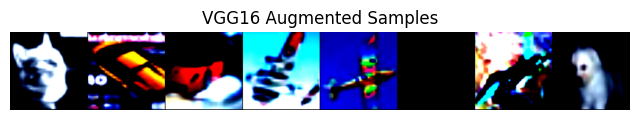

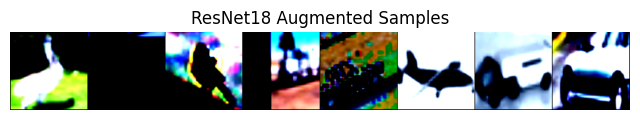

In [7]:
# Helper function to show a grid of images
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))  # CHW -> HWC
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    if title: plt.title(title)
    plt.show()

# Show VGG16-preprocessed batch
vgg_images, vgg_labels = next(iter(vgg_trainloader))
imshow(torchvision.utils.make_grid(vgg_images[:8]), title="VGG16 Augmented Samples")

# Show ResNet18-preprocessed batch
resnet_images, resnet_labels = next(iter(resnet_trainloader))
imshow(torchvision.utils.make_grid(resnet_images[:8]), title="ResNet18 Augmented Samples")

Examine the CIFAR-10 images after applying transformations. Identify two classes you believe are most difficult for the models to distinguish and explain why.

**Written Answer:** Catsvs Dogs and Cars versus trucks. They both look similar.

Question 2: Model Definitions – VGG16 and ResNet18
1. Load pre-trained VGG16 and ResNet18 models from torchvision.
2. Freeze all convolutional layers initially, then unfreeze the last convolutional block in both models.
3. Modify the classifier layers to accommodate CIFAR-10 classification (10 output classes).

In [8]:
# Load pre-trained models
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 122MB/s]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 96.6MB/s]


In [9]:
# Freeze all parameters
for param in vgg16.features.parameters():
    param.requires_grad = False

# Unfreeze the last conv block (features[24:] includes last conv block and maxpool)
for param in vgg16.features[24:].parameters():
    param.requires_grad = True

# Freeze all parameters
for param in resnet18.parameters():
    param.requires_grad = False

# Unfreeze the last conv block (layer4)
for param in resnet18.layer4.parameters():
    param.requires_grad = True

In [10]:
vgg16.classifier[6] = nn.Linear(in_features=4096, out_features=10)
resnet18.fc = nn.Linear(in_features=resnet18.fc.in_features, out_features=10)


Explain the concept of transfer learning and its specific advantages when applied to CIFAR-10 classification using models like VGG16 and ResNet18.

Transfer learning in ML is when we use pre built mdoels, that were trained in one task but then used and trained on another task. It saves time and costs.

Classification models like VGG16 and ResNet18 are trained on million of images, learning more of the image whether it is texture, edge and shapes. CIFAR is simialr and we can benefit:
Faster convergence: Starting with model already built
Better performance: Better learning than using a model built from scratch
Cheaper: Cheaper costs and less time.

**Written Answer:**

## Question 3: Training the Models
1. Define the loss function (Cross-Entropy Loss).
2. Initialize Adam optimizers for each model with a learning rate of 0.001.
3. Train each model separately. Train for 5 epochs, monitor loss, and ensure proper updating of model weights.

In [11]:
criterion = nn.CrossEntropyLoss()

In [12]:
# Training function
vgg_optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16.parameters()), lr=0.001)
resnet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=0.001)

In [15]:
# Train models
def train_model(model, trainloader, optimizer, name="Model"):
    # Check if GPU (CUDA) is available, else use CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    for epoch in range(5):  # Train for 5 epochs
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        avg_loss = running_loss / len(trainloader.dataset)
        print(f"[{name}] Epoch {epoch+1}/5 - Loss: {avg_loss:.4f}")

In [18]:
# Train VGG16
train_model(vgg16, vgg_trainloader, vgg_optimizer, name="VGG16")

[VGG16] Epoch 1/5 - Loss: 1.7433
[VGG16] Epoch 2/5 - Loss: 1.4160
[VGG16] Epoch 3/5 - Loss: 1.2540
[VGG16] Epoch 4/5 - Loss: 1.1132
[VGG16] Epoch 5/5 - Loss: 1.0526


In [19]:
# Train ResNet18
train_model(resnet18, resnet_trainloader, resnet_optimizer, name="ResNet18")

[ResNet18] Epoch 1/5 - Loss: 1.0722
[ResNet18] Epoch 2/5 - Loss: 0.7661
[ResNet18] Epoch 3/5 - Loss: 0.6601
[ResNet18] Epoch 4/5 - Loss: 0.5835
[ResNet18] Epoch 5/5 - Loss: 0.5477


Compare training behaviours of VGG16 and ResNet18. Which model trains faster and why?

ResNet18 outperforms the VGG16 in both time and convergence to the resylt. This is due to how the ResNet18 works. It uses residual connections (skip connections) which allow gradients to flow more effectively through the network. This helps avoid vanishing gradients and leads to better optimization during backpropagation. it is also shallower and lighter.

**Written Answer:**

## Question 4: Model Evaluation
1. Define a function to calculate the accuracy of each model on the test set.
2. Evaluate both models separately.
3. Plot confusion matrices for each model using `sklearn.metrics.confusion_matrix` and `ConfusionMatrixDisplay`.
4. Interpret results based on model-specific accuracy and confusion matrix insights.

In [22]:
def evaluate_accuracy(model, testloader, name="Model"):
    # Check if GPU (CUDA) is available, else use CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Define device here
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"{name} Accuracy on Test Set: {accuracy:.2f}%")
    return all_labels, all_preds

In [23]:
# Evaluate VGG16
vgg_labels, vgg_preds = evaluate_accuracy(vgg16, vgg_testloader, name="VGG16")

# Evaluate ResNet18
resnet_labels, resnet_preds = evaluate_accuracy(resnet18, resnet_testloader, name="ResNet18")

VGG16 Accuracy on Test Set: 62.60%
ResNet18 Accuracy on Test Set: 72.20%


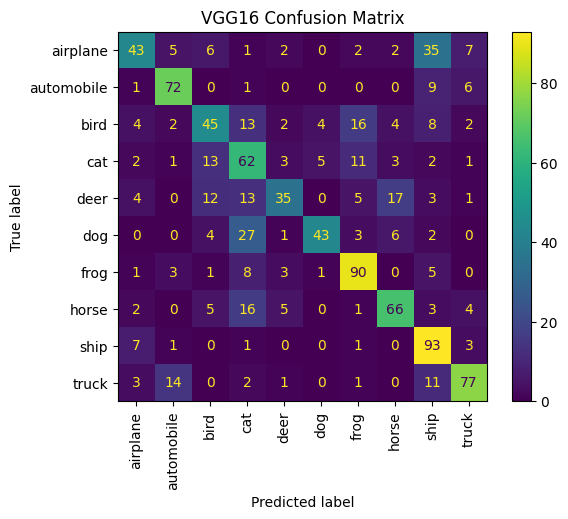

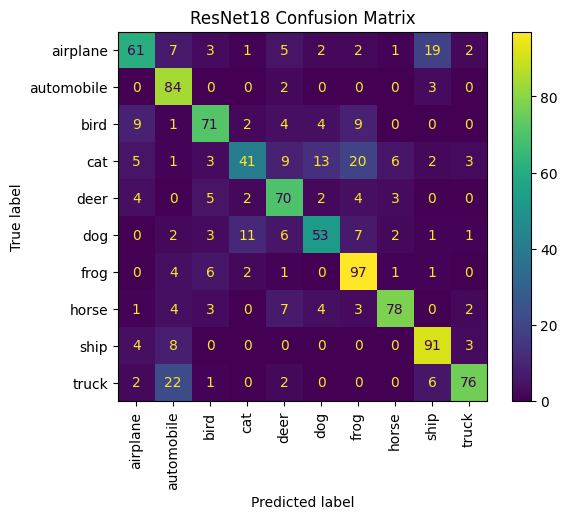

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# VGG16 Confusion Matrix
cm_vgg = confusion_matrix(vgg_labels, vgg_preds)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=classes)
disp_vgg.plot(xticks_rotation='vertical')
plt.title("VGG16 Confusion Matrix")
plt.show()

# ResNet18 Confusion Matrix
cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=classes)
disp_resnet.plot(xticks_rotation='vertical')
plt.title("ResNet18 Confusion Matrix")
plt.show()


As discussed earlier ResNet does a way better job in all aspects due to how it operates

Suggest two additional improvements specifically tailored for the less accurate model. Clearly explain your rationale for each suggestion.

Apparebntly we can reduce the time it takes for VGG16 to converge by restricting how much it learns. Or train it on less layers